# Required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Setup

## Dataset downloading

In [2]:
data = load_breast_cancer()
X = data.data     
y = data.target

## Dataset splitting

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

scaler = StandardScaler()
scaler.fit(X_train) 

X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

## Decision Tree class

In [4]:
class TreeNode:
    def __init__(self, depth=0, max_depth=None):
        self.depth = depth
        self.max_depth = max_depth
        self.feature_idx = None
        self.threshold = None
        self.left = None
        self.right = None
        self.label = None

## Function to calculate entropy

In [5]:
def entropy(y):
    n = len(y)
    if n == 0:
        return 0
    counts = np.bincount(y)
    probs = counts / n
    probs = probs[probs > 0]  
    return -np.sum(probs * np.log2(probs))

## Function to calculate information_gain

In [6]:
def information_gain(y_parent, y_left, y_right):
    n = len(y_parent)
    n_left = len(y_left)
    n_right = len(y_right)
    gain = entropy(y_parent) - (n_left/n)*entropy(y_left) - (n_right/n)*entropy(y_right)
    return gain

## Finding the best feature to split on it

In [7]:
feature_importance = np.zeros(X.shape[1])
def best_split(X, y, feature_indices=None):
    global feature_importance
    n_samples, n_features = X.shape
    best_gain = -1
    split_idx, split_thresh = None, None
    
    if feature_indices is None:
        features_to_consider = range(n_features)
    else:
        features_to_consider = feature_indices

    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])
        for thresh in thresholds:
            left_mask = X[:, feature] <= thresh
            right_mask = ~left_mask
            y_left, y_right = y[left_mask], y[right_mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            gain = information_gain(y, y_left, y_right)
            if gain > best_gain:
                best_gain = gain
                split_idx = feature
                split_thresh = thresh
    feature_importance[split_idx] += best_gain
    return split_idx, split_thresh, best_gain

## Building the normal tree

In [8]:
def build_tree_normal(X, y, depth=0, max_depth=None, min_samples_split=2):
    node = TreeNode(depth=depth, max_depth=max_depth)

    if len(np.unique(y)) == 1 or (max_depth is not None and depth >= max_depth) or len(y) < min_samples_split:
        node.label = Counter(y).most_common(1)[0][0]
        return node

    feature_idx, threshold, gain = best_split(X, y)
    if gain == 0:
        node.label = Counter(y).most_common(1)[0][0] 
        return node

    node.feature_idx = feature_idx
    node.threshold = threshold

    left_mask = X[:, feature_idx] <= threshold
    right_mask = ~left_mask

    node.left = build_tree_normal(X[left_mask], y[left_mask], depth+1, max_depth, min_samples_split)
    node.right = build_tree_normal(X[right_mask], y[right_mask], depth+1, max_depth, min_samples_split)

    return node

## Building the random forest

In [9]:
def build_tree_random_forest(X, y, depth=0, max_depth=None, min_samples_split=2, max_features=None, rng=None):
    node = TreeNode(depth=depth, max_depth=max_depth)

    if len(np.unique(y)) == 1 or (max_depth is not None and depth >= max_depth) or len(y) < min_samples_split:
        node.label = Counter(y).most_common(1)[0][0]
        return node

    n_features = X.shape[1]
    if max_features is None:
        feat_idxs = None
    else:
        if max_features >= n_features:
            feat_idxs = list(range(n_features))
        else:
            if isinstance(rng, np.random.RandomState):
                feat_idxs = rng.choice(n_features, size=max_features, replace=False)
            else:
                feat_idxs = np.array(random.sample(range(n_features), k=max_features))

    feature_idx, threshold, gain = best_split(X, y, feature_indices=feat_idxs)
    if feature_idx is None or gain <= 0:
        node.label = Counter(y).most_common(1)[0][0]
        return node

    node.feature_idx = int(feature_idx)
    node.threshold = float(threshold)

    left_mask = X[:, node.feature_idx] <= node.threshold
    right_mask = ~left_mask

    node.left = build_tree_random_forest(X[left_mask], y[left_mask], depth+1, max_depth, min_samples_split, max_features, rng)
    node.right = build_tree_random_forest(X[right_mask], y[right_mask], depth+1, max_depth, min_samples_split, max_features, rng)

    return node

## Predicting one record

In [10]:
def predict_one(node, x):
    if node.label is not None:
        return node.label
    if x[node.feature_idx] <= node.threshold:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)

## helper function to make it easier

In [11]:
def predict(node, X):
    return np.array([predict_one(node, sample) for sample in X])

## For random forest chosing random sample with replacement

In [12]:
def bootstrap_sample(X, y, rng):
    n = X.shape[0]
    indices = rng.randint(0, n, size=n)
    return X[indices], y[indices]

## Random Forest class and setup

In [13]:
class RandomForest:
    def __init__(self, n_trees=10, max_depth=None, min_samples_split=2, max_features=None, random_state=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []
        self.rng = np.random.RandomState(random_state)

    def fit(self, X, y):
        self.trees = []
        for t in range(self.n_trees):
            X_bs, y_bs = bootstrap_sample(X, y, self.rng)
            tree_rng = np.random.RandomState(self.rng.randint(0, 2**31 - 1))
            tree = build_tree_random_forest(X_bs, y_bs, depth=0, max_depth=self.max_depth,
                              min_samples_split=self.min_samples_split,
                              max_features=self.max_features, rng=tree_rng)
            self.trees.append(tree)

    def predict(self, X):
        all_preds = np.array([predict(tree, X) for tree in self.trees])
        preds = []
        for col in all_preds.T:
            vals, counts = np.unique(col, return_counts=True)
            preds.append(vals[np.argmax(counts)])
        return np.array(preds)

    def predict_proba(self, X):
        all_preds = np.array([predict(tree, X) for tree in self.trees])
        avg = np.mean(all_preds == 1, axis=0)
        return np.vstack([1 - avg, avg]).T

# Testing paramters on validation data to get the best params

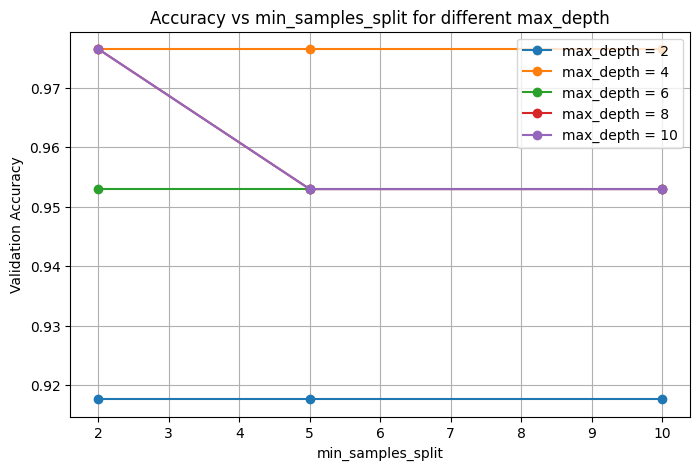


BEST PARAMETERS: (4, 2) | Accuracy = 0.9764705882352941


In [14]:
max_depths = [2,4,6,8,10]
min_splits = [2,5,10]

results = np.zeros((len(max_depths), len(min_splits)))

best_acc = 0
best_params = None

for i, md in enumerate(max_depths):
    for j, ms in enumerate(min_splits):
        tree = build_tree_normal(X_train_s, y_train, max_depth=md, min_samples_split=ms)
        preds = predict(tree, X_val_s)
        acc = accuracy_score(y_val, preds)

        results[i, j] = acc
        
        if acc > best_acc:
            best_acc = acc
            best_params = (md, ms)

plt.figure(figsize=(8,5))
for i, md in enumerate(max_depths):
    plt.plot(min_splits, results[i, :], marker='o', label=f"max_depth = {md}")

plt.xlabel("min_samples_split")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy vs min_samples_split for different max_depth")
plt.legend()
plt.grid(True)
plt.show()

print("\nBEST PARAMETERS:", best_params, "| Accuracy =", best_acc)

# Print the faeture importance calculated above with ranking

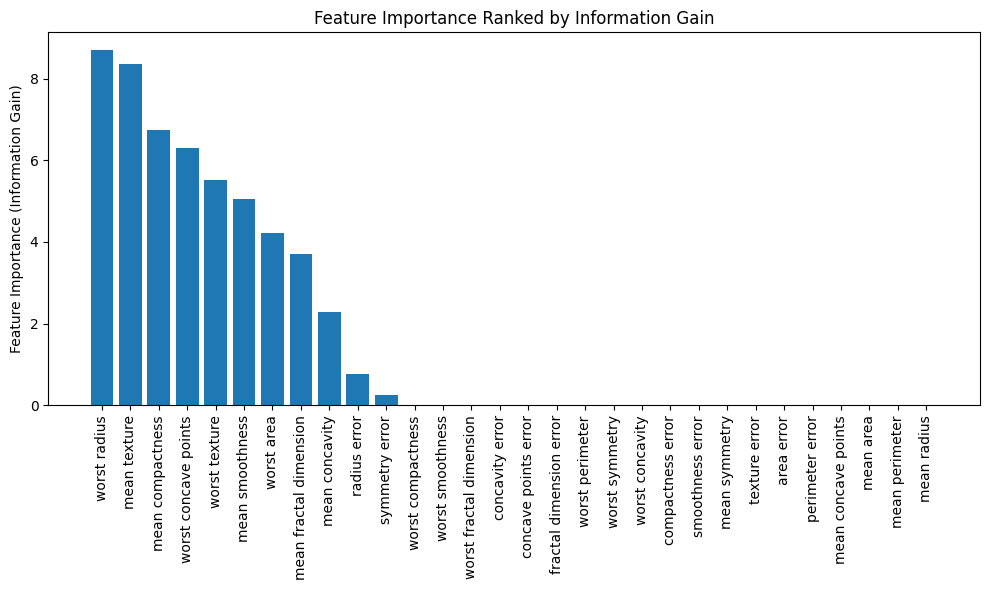

In [15]:
fi_sorted = np.argsort(feature_importance)[::-1]
names_sorted = data.feature_names[fi_sorted]
values_sorted = feature_importance[fi_sorted]

plt.figure(figsize=(10,6))
plt.bar(range(len(values_sorted)), values_sorted)
plt.xticks(range(len(values_sorted)), names_sorted, rotation=90)
plt.ylabel("Feature Importance (Information Gain)")
plt.title("Feature Importance Ranked by Information Gain")
plt.tight_layout()
plt.show()

# Building the normal tree and predecting

In [16]:
best_md, best_ms = best_params
final_tree = build_tree_normal(
    np.vstack([X_train_s, X_val_s]),
    np.hstack([y_train, y_val]),
    max_depth=best_md,
    min_samples_split=best_ms
)

test_pred = predict(final_tree, X_test_s)

# Building random forest and getting the best configurations for it

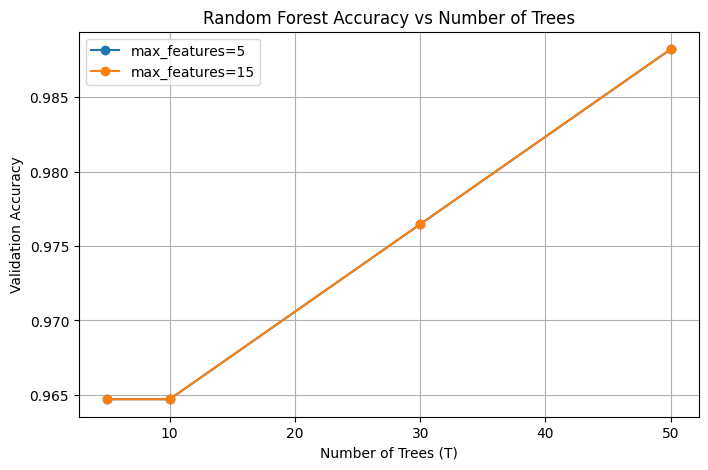

Best RF on validation: (50, 5) acc= 0.9882352941176471


In [17]:
best_md, best_ms = best_params
d = X_train_s.shape[1]
max_features_options = [int(np.floor(np.sqrt(d))), d // 2]
T_options = [5, 10, 30, 50]

rf_results = {}
best_rf_acc = -1
best_rf_config = None

plt.figure(figsize=(8,5))

for mf in max_features_options:
    accs = []
    for T in T_options:
        rf = RandomForest(n_trees=T, max_depth=best_md, min_samples_split=best_ms, max_features=mf, random_state=42)
        rf.fit(X_train_s, y_train)
        val_pred = rf.predict(X_val_s)
        acc = accuracy_score(y_val, val_pred)
        rf_results[(T, mf)] = acc
        accs.append(acc)
        if acc > best_rf_acc:
            best_rf_acc = acc
            best_rf_config = (T, mf)
    plt.plot(T_options, accs, marker='o', label=f"max_features={mf}")

plt.xlabel("Number of Trees (T)")
plt.ylabel("Validation Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.legend()
plt.grid(True)
plt.show()

print("Best RF on validation:", best_rf_config, "acc=", best_rf_acc)

# Applying random forest on test set

In [18]:
T_best, mf_best = best_rf_config
rf_best = RandomForest(n_trees=T_best, max_depth=best_md, min_samples_split=best_ms, max_features=mf_best, random_state=0)
X_trainval = np.vstack([X_train_s, X_val_s])
y_trainval = np.hstack([y_train, y_val])
rf_best.fit(X_trainval, y_trainval)

y_test_pred_rf = rf_best.predict(X_test_s)

print("\n--- Random Forest Test Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Precision:", precision_score(y_test, y_test_pred_rf))
print("Recall:", recall_score(y_test, y_test_pred_rf))
print("F1:", f1_score(y_test, y_test_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_rf))


--- Random Forest Test Evaluation ---
Accuracy: 0.8953488372093024
Precision: 0.8947368421052632
Recall: 0.9444444444444444
F1: 0.918918918918919
Confusion Matrix:
 [[26  6]
 [ 3 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.81      0.85        32
           1       0.89      0.94      0.92        54

    accuracy                           0.90        86
   macro avg       0.90      0.88      0.89        86
weighted avg       0.90      0.90      0.89        86



# Applying normal tree on test set

In [19]:
best_tree = build_tree_normal(X_trainval, y_trainval, max_depth=best_md, min_samples_split=best_ms, depth=0)
y_test_pred_tree = predict(best_tree, X_test_s)

print("\n--- Single Tree Test Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_tree))
print("Precision:", precision_score(y_test, y_test_pred_tree))
print("Recall:", recall_score(y_test, y_test_pred_tree))
print("F1:", f1_score(y_test, y_test_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred_tree))


--- Single Tree Test Evaluation ---
Accuracy: 0.8837209302325582
Precision: 0.8928571428571429
Recall: 0.9259259259259259
F1: 0.9090909090909091
Confusion Matrix:
 [[26  6]
 [ 4 50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84        32
           1       0.89      0.93      0.91        54

    accuracy                           0.88        86
   macro avg       0.88      0.87      0.87        86
weighted avg       0.88      0.88      0.88        86



# Analysis and compare between normal decision tree and random forest

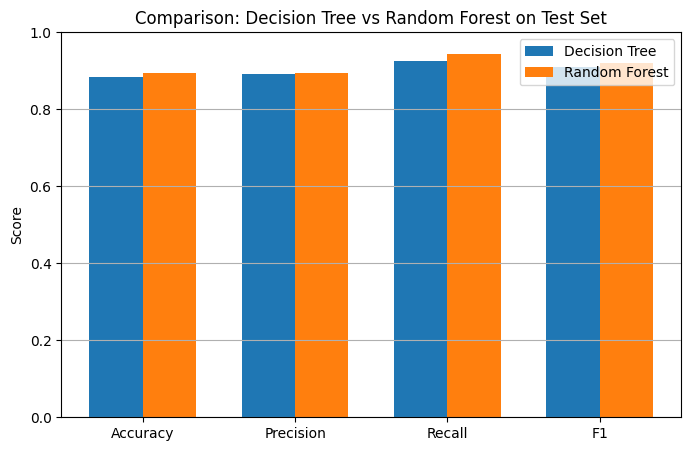

In [20]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
tree_metrics = [
    accuracy_score(y_test, y_test_pred_tree),
    precision_score(y_test, y_test_pred_tree),
    recall_score(y_test, y_test_pred_tree),
    f1_score(y_test, y_test_pred_tree)
]

rf_metrics = [
    accuracy_score(y_test, y_test_pred_rf),
    precision_score(y_test, y_test_pred_rf),
    recall_score(y_test, y_test_pred_rf),
    f1_score(y_test, y_test_pred_rf)
]

x = range(len(metrics_names))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar([i - width/2 for i in x], tree_metrics, width=width, label="Decision Tree")
plt.bar([i + width/2 for i in x], rf_metrics, width=width, label="Random Forest")
plt.xticks(x, metrics_names)
plt.ylabel("Score")
plt.title("Comparison: Decision Tree vs Random Forest on Test Set")
plt.ylim(0,1)
plt.legend()
plt.grid(axis='y')
plt.show()

### Here you can notice that random forest is a bit better than normal decision tree and it's because it took into considration the overfitting which handled by the random samples and random features to consider. Also random forest can be better if we take other `best_params` which makes the same accuracy for normal decision tree.